In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
train_df = pd.read_csv('data/채널정보_with_segment.csv')

In [3]:
subset = train_df[train_df['기준년월'] == 201811]

In [4]:
# 숫자형 데이터만 추출하고 결측치 제거
numeric_data = subset.select_dtypes(include='number')
clean_data = numeric_data.dropna()

# 해당 행만 subset에서도 추출
subset_clean = subset.loc[clean_data.index]

# 정규화 및 PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaled = StandardScaler().fit_transform(clean_data)
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

# 결과 DataFrame 구성
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'], index=clean_data.index)
pca_df['Segment'] = subset_clean['Segment'].values  # 인덱스 맞춰서 추가


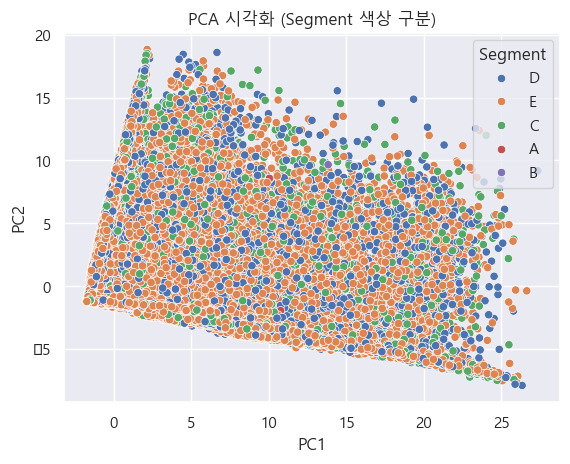

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Segment')
plt.title('PCA 시각화 (Segment 색상 구분)')
plt.show()


In [6]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 수치형 변수 선택 및 정규화
numeric_data = subset.select_dtypes(include='number')
imputed_data = numeric_data.fillna(numeric_data.mean())  # 결측값 처리
scaled_data = StandardScaler().fit_transform(imputed_data)

# 2. PCA 수행
pca = PCA(n_components=2)
pca.fit(scaled_data)

# 3. 구성 성분 확인
loadings = pd.DataFrame(
    pca.components_.T,  # 전치행렬: 변수 x 주성분
    columns=['PC1', 'PC2'],
    index=numeric_data.columns
)

# 4. 절대값 기준으로 가장 영향력 있는 변수 확인
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False)

print("📌 PC1에 가장 영향을 준 변수:")
print(top_pc1.head(10))
print("\n📌 PC2에 가장 영향을 준 변수:")
print(top_pc2.head(10))


📌 PC1에 가장 영향을 준 변수:
인입횟수_IB_R6M       0.262535
인입일수_IB_R6M       0.262334
상담건수_R6M          0.262208
인입일수_ARS_R6M      0.253079
인입월수_IB_R6M       0.251946
이용메뉴건수_IB_R6M     0.247880
인입월수_ARS_R6M      0.246847
인입후경과월_IB_R6M     0.245782
인입횟수_ARS_B0M      0.230889
이용메뉴건수_ARS_B0M    0.230306
Name: PC1, dtype: float64

📌 PC2에 가장 영향을 준 변수:
방문횟수_앱_B0M        0.320096
방문일수_앱_B0M        0.319503
방문일수_앱_R6M        0.309782
방문월수_앱_R6M        0.302360
방문후경과월_앱_R6M      0.294056
홈페이지_금융건수_R6M     0.277241
홈페이지_선결제건수_R6M    0.275214
홈페이지_금융건수_R3M     0.274792
홈페이지_선결제건수_R3M    0.272473
방문월수_PC_R6M       0.158509
Name: PC2, dtype: float64


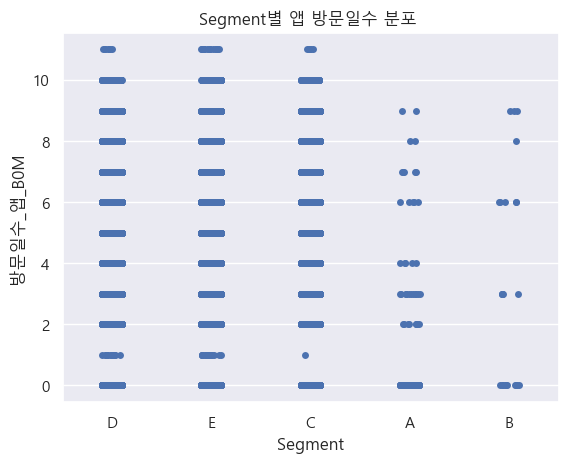

In [7]:
sns.stripplot(x='Segment', y='방문일수_앱_B0M', data=subset, jitter=True)
plt.title('Segment별 앱 방문일수 분포 ')
plt.show()

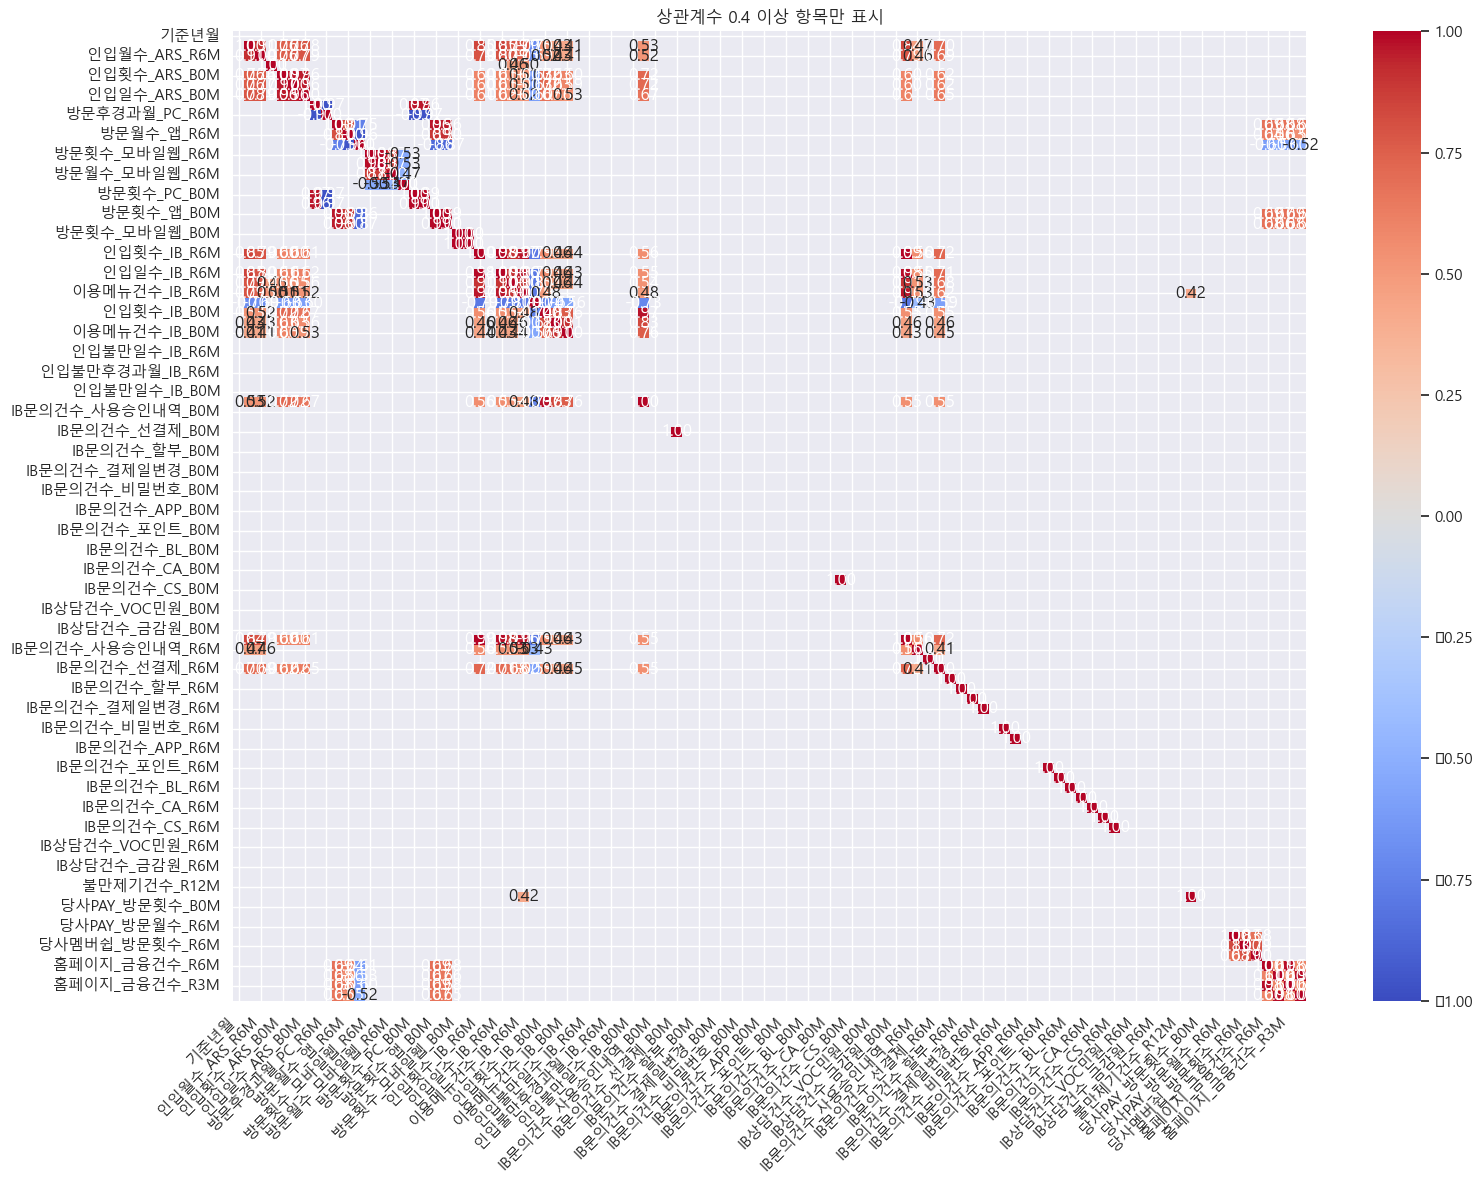

In [8]:
# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 절대값 기준 필터링 (예: 0.5 이상만)
filtered_corr = corr.copy()
filtered_corr[np.abs(filtered_corr) < 0.4] = np.nan

plt.figure(figsize=(16, 12))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, mask=filtered_corr.isnull())
plt.title('상관계수 0.4 이상 항목만 표시')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
import numpy as np

# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 상삼각 (자기 자신 제외)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
filtered = corr.where(mask)

# 절대값 기준 필터링
result = (
    filtered.stack()
    .reset_index()
    .rename(columns={'level_0': '변수1', 'level_1': '변수2', 0: '상관계수'})
)

# 상관계수 0.4 이상만 추출
result = result[result['상관계수'].abs() >= 0.98]
result = result.sort_values(by='상관계수', ascending=False)

# 결과 출력
print(result)


                 변수1             변수2      상관계수
893    방문횟수_모바일웹_B0M   방문일수_모바일웹_B0M  1.000000
976      인입횟수_IB_R6M        상담건수_R6M  0.992598
816       방문횟수_앱_B0M      방문일수_앱_B0M  0.990759
735      방문횟수_PC_B0M     방문일수_PC_B0M  0.986656
966      인입횟수_IB_R6M     인입일수_IB_R6M  0.984685
1594  홈페이지_선결제건수_R6M  홈페이지_선결제건수_R3M  0.984366
1010     인입일수_IB_R6M        상담건수_R6M  0.983170
1591   홈페이지_금융건수_R6M   홈페이지_금융건수_R3M  0.981340
561    방문횟수_모바일웹_R6M   방문일수_모바일웹_R6M  0.980086


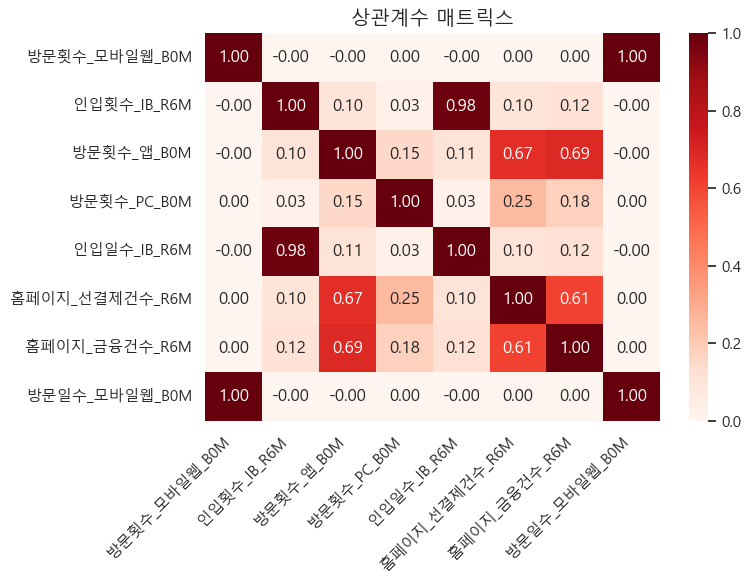

In [10]:
# 원하는 변수 리스트
cols = [
    '방문횟수_모바일웹_B0M',
    '인입횟수_IB_R6M',
    '방문횟수_앱_B0M',
    '방문횟수_PC_B0M',
    '인입일수_IB_R6M',
    '홈페이지_선결제건수_R6M',
    '홈페이지_금융건수_R6M',
    '방문일수_모바일웹_B0M'
]

# 숫자형 컬럼만 필터링되어 있어야 함
corr = subset[cols].corr()

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title('상관계수 매트릭스', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
import numpy as np

# 상관계수 계산
corr = subset.corr(numeric_only=True)

# 상삼각 행렬 (자기 자신 제외)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
upper = corr.where(mask)

# 0.8 이상인 항목 필터링
high_corr = upper[abs(upper) >= 0.98]

# 컬럼 이름 추출 (중복 없이)
cols = set(high_corr.dropna(how='all').index) | set(high_corr.dropna(axis=1, how='all').columns)
selected_columns = sorted(cols)

# 출력
print("상관계수 0.98 이상인 컬럼 목록:")
for col in selected_columns:
    print(col)


상관계수 0.98 이상인 컬럼 목록:
방문일수_PC_B0M
방문일수_모바일웹_B0M
방문일수_모바일웹_R6M
방문일수_앱_B0M
방문횟수_PC_B0M
방문횟수_모바일웹_B0M
방문횟수_모바일웹_R6M
방문횟수_앱_B0M
상담건수_R6M
인입일수_IB_R6M
인입횟수_IB_R6M
홈페이지_금융건수_R3M
홈페이지_금융건수_R6M
홈페이지_선결제건수_R3M
홈페이지_선결제건수_R6M


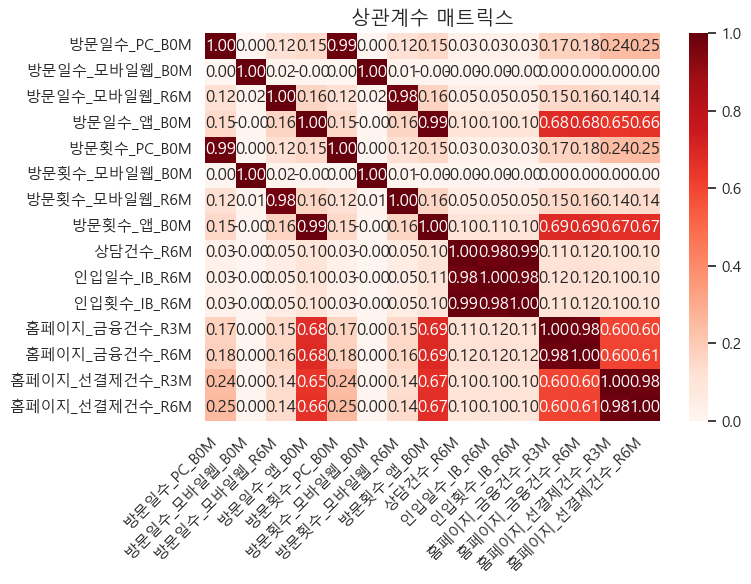

In [12]:
# 원하는 변수 리스트
cols = [
    '방문일수_PC_B0M',
    '방문일수_모바일웹_B0M',
    '방문일수_모바일웹_R6M',
    '방문일수_앱_B0M',
    '방문횟수_PC_B0M',
    '방문횟수_모바일웹_B0M',
    '방문횟수_모바일웹_R6M',
    '방문횟수_앱_B0M',
    '상담건수_R6M',
    '인입일수_IB_R6M',
    '인입횟수_IB_R6M',
    '홈페이지_금융건수_R3M',
    '홈페이지_금융건수_R6M',
    '홈페이지_선결제건수_R3M',
    '홈페이지_선결제건수_R6M'
]

# 숫자형 컬럼만 필터링되어 있어야 함
corr = subset[cols].corr()

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title('상관계수 매트릭스', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
